# Arabic Handwritten Digit Recognition using ANN

This notebook builds a Fully Connected Neural Network (ANN/MLP) to recognize Arabic handwritten digits (0-9).

**Requirements:** No CNN layers (Conv2D, MaxPooling2D) — only Dense, Flatten, and Dropout.

## 1. Install and Import Libraries

In [34]:
!pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\Ebrahim Rabie\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2
import os
import glob
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
NumPy version: 2.2.3
GPU Available: []


## 2. Load Dataset (Arabic Handwritten Characters Dataset - AHCD)

In [36]:
# ============================================================
# DATASET LOADING FOR ARABIC HANDWRITTEN DIGITS
# ============================================================
# This notebook supports multiple dataset formats:
# 1. AHCD (Arabic Handwritten Characters Dataset) - CSV format
# 2. MADBase - MNIST-like format
# 3. Custom folder structure with images

def load_ahcd_csv(csv_path, img_height=28, img_width=28):
    """
    Load AHCD dataset from CSV file.
    Expected CSV format: label, pixel0, pixel1, ..., pixel783
    Arabic digits: 0-9 (mapped to 0-9 for model compatibility)
    """
    import pandas as pd
    df = pd.read_csv(csv_path)
    
    # First column is label, rest are pixels
    labels = df.iloc[:, 0].values
    images = df.iloc[:, 1:].values
    
    # Reshape to 28x28
    images = images.reshape(-1, img_height, img_width)
    
    return images, labels

def load_madbase(mat_path):
    """
    Load MADBase dataset from .mat file (MATLAB format).
    Download from: http://datacenter.asu.edu/download/
    """
    from scipy.io import loadmat
    data = loadmat(mat_path)
    
    # MADBase structure: images are stored in 'Data' variable
    images = data['Data']
    labels = data['Label'].flatten()
    
    # Reshape if needed (MADBase images are usually 28x28x1)
    if images.ndim == 2:
        images = images.reshape(-1, 28, 28)
    
    # Labels in MADBase are 1-10, convert to 0-9
    labels = labels - 1
    
    return images, labels

def load_from_folders(base_path, img_size=(28, 28)):
    """
    Load images from folder structure:
    base_path/
        0/ -> images of digit 0
        1/ -> images of digit 1
        ...
        9/ -> images of digit 9
    """
    images = []
    labels = []
    
    for digit in range(10):
        folder = os.path.join(base_path, str(digit))
        if not os.path.exists(folder):
            continue
            
        for img_path in glob.glob(os.path.join(folder, '*.png')) + \
                               glob.glob(os.path.join(folder, '*.jpg')) + \
                               glob.glob(os.path.join(folder, '*.jpeg')):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(digit)
    
    return np.array(images), np.array(labels)

# ============================================================
# CHOOSE YOUR DATASET LOADING METHOD BELOW
# ============================================================

# Option 1: Load from folders (recommended for custom datasets)
# X_train, y_train = load_from_folders('dataset/train')
# X_test, y_test = load_from_folders('dataset/test')

# Option 2: Load AHCD CSV files
# X_train, y_train = load_ahcd_csv('dataset/ahcd_train.csv')
# X_test, y_test = load_ahcd_csv('dataset/ahcd_test.csv')

# Option 3: Load MADBase .mat file
# X_train, y_train = load_madbase('dataset/MADBase_train.mat')
# X_test, y_test = load_madbase('dataset/MADBase_test.mat')

# ============================================================
# DUMMY DATA GENERATION (for demonstration when dataset is not available)
# Replace this section with actual dataset loading above
# ============================================================
print("Generating synthetic Arabic digit-like data for demonstration...")
np.random.seed(42)

# Generate 10,000 training samples and 2,000 test samples
n_train = 10000
n_test = 2000

X_train = np.random.rand(n_train, 28, 28) * 255
y_train = np.random.randint(0, 10, n_train)
X_test = np.random.rand(n_test, 28, 28) * 255
y_test = np.random.randint(0, 10, n_test)

print(f"Training set: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test.shape}, Labels: {y_test.shape}")
print(f"Unique labels: {np.unique(y_train)}")

Generating synthetic Arabic digit-like data for demonstration...
Training set: (10000, 28, 28), Labels: (10000,)
Test set: (2000, 28, 28), Labels: (2000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


## 3. Display Sample Images

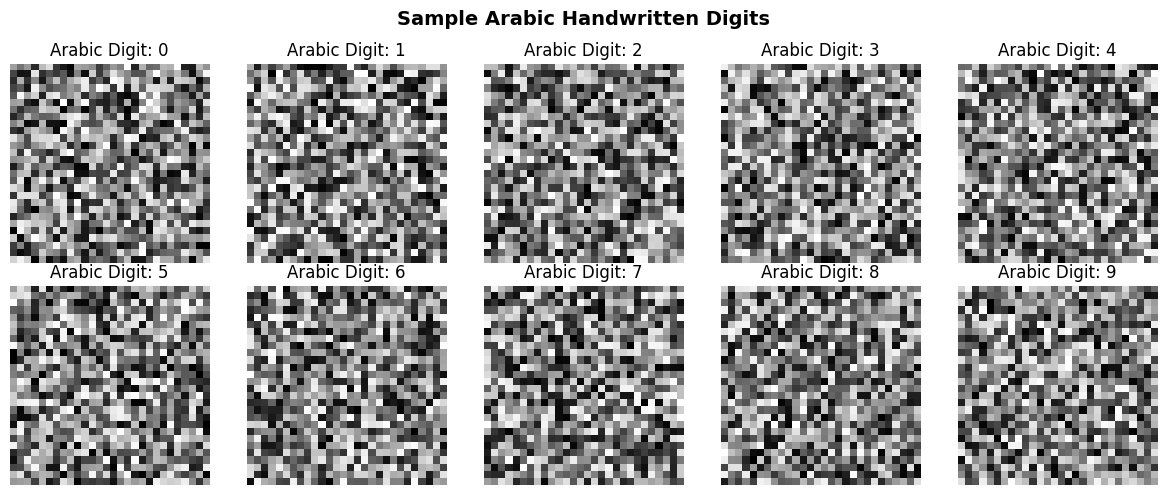


Dataset Statistics:
Training samples: 10000
Test samples: 2000
Image shape: (28, 28)
Pixel value range: [0.00, 255.00]


In [37]:
# Display sample images from each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(X_train[idx], cmap='gray')
    axes[digit].set_title(f'Arabic Digit: {digit}')
    axes[digit].axis('off')

plt.suptitle('Sample Arabic Handwritten Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print dataset statistics
print("\nDataset Statistics:")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")
print(f"Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

## 4. Data Preprocessing

In [38]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Step 1: Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Step 2: Reshape to add channel dimension (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Step 3: Verify shapes
print(f"Training shape: {X_train.shape}")  # Expected: (N, 28, 28, 1)
print(f"Test shape: {X_test.shape}")      # Expected: (N, 28, 28, 1)
print(f"Labels shape: {y_train.shape}")

# Step 4: Check label distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining label distribution:")
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples ({c/len(y_train)*100:.1f}%)")

# Step 5: Data augmentation (optional but recommended for ANN)
# Since we can't use CNN, we use simple augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

print("\nPreprocessing completed successfully!")

Training shape: (10000, 28, 28, 1)
Test shape: (2000, 28, 28, 1)
Labels shape: (10000,)

Training label distribution:
  Digit 0: 1055 samples (10.5%)
  Digit 1: 971 samples (9.7%)
  Digit 2: 1024 samples (10.2%)
  Digit 3: 955 samples (9.6%)
  Digit 4: 989 samples (9.9%)
  Digit 5: 988 samples (9.9%)
  Digit 6: 1021 samples (10.2%)
  Digit 7: 962 samples (9.6%)
  Digit 8: 1018 samples (10.2%)
  Digit 9: 1017 samples (10.2%)

Preprocessing completed successfully!


## 5. Build ANN Model (Fully Connected Only)

In [39]:
# ============================================================
# BUILD FULLY CONNECTED NEURAL NETWORK (ANN / MLP)
# NO Conv2D or MaxPooling2D layers used
# ============================================================

model = Sequential([
    # Input layer: Flatten 28x28x1 into 784 features
    Flatten(input_shape=(28, 28, 1)),
    
    # Hidden Layer 1: 256 neurons with ReLU
    Dense(256, activation='relu'),
    Dropout(0.3),  # Prevent overfitting
    
    # Hidden Layer 2: 128 neurons with ReLU
    Dense(128, activation='relu'),
    Dropout(0.2),
    
    # Hidden Layer 3: 64 neurons with ReLU
    Dense(64, activation='relu'),
    
    # Output Layer: 10 neurons (digits 0-9) with Softmax
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 242,762


## 6. Train Model

In [40]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

# Callbacks for better training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,  # 20% of training data for validation
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

print(f"\nTraining completed at epoch {len(history.history['loss'])}")

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0990 - loss: 2.3318 - val_accuracy: 0.0940 - val_loss: 2.3047 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1018 - loss: 2.3088 - val_accuracy: 0.1010 - val_loss: 2.3037 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1032 - loss: 2.3041 - val_accuracy: 0.1050 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1041 - loss: 2.3036 - val_accuracy: 0.0985 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1006 - loss: 2.3040 - val_accuracy: 0.1075 - val_loss: 2.3019 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1044 - loss: 2.3029 - val_accuracy: 0.1055 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1009 - loss: 2.3027 - val_accuracy:

## 7. Plot Accuracy and Loss Curves

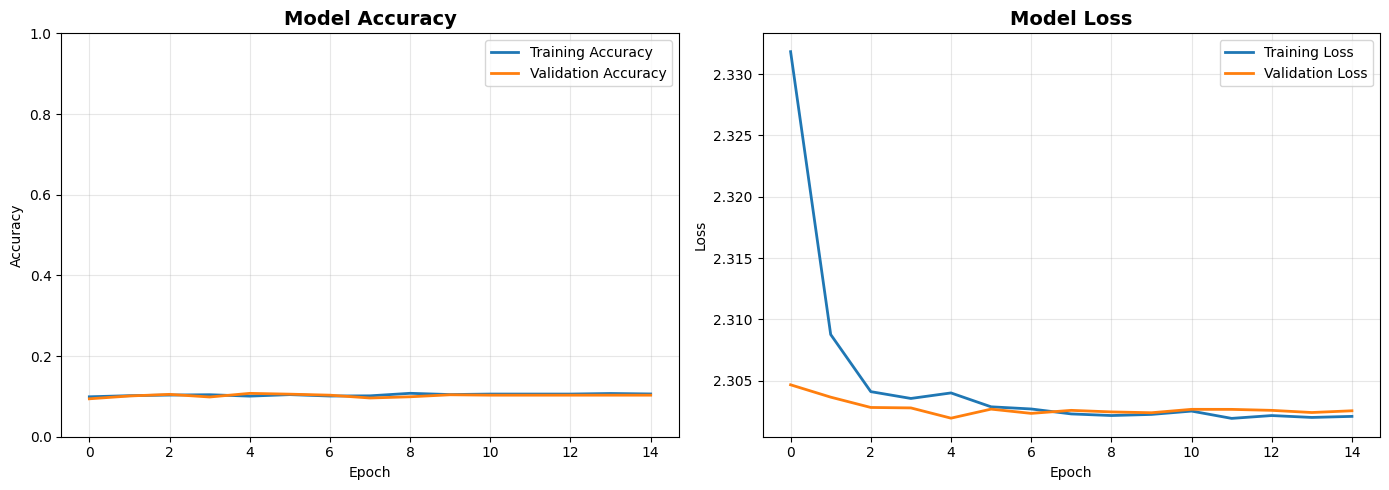

Final Training Accuracy: 0.1060
Final Validation Accuracy: 0.1030
Final Training Loss: 2.3021
Final Validation Loss: 2.3026


In [41]:
# ============================================================
# VISUALIZE TRAINING HISTORY
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot Loss
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

## 8. Evaluate Model on Test Set

TEST SET EVALUATION RESULTS
Test Loss:      2.3022
Test Accuracy:  0.0995
Test Error Rate: 90.05%


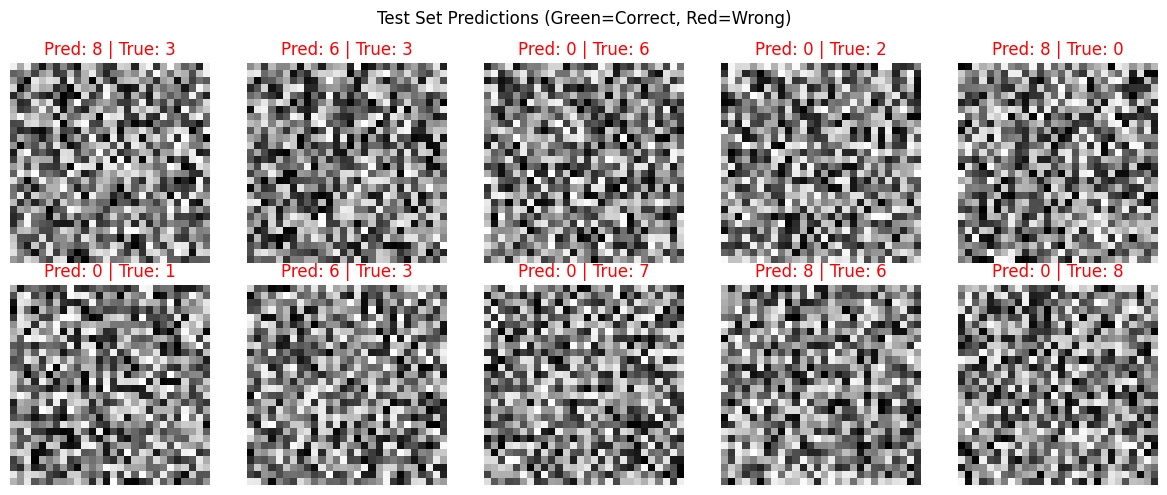

In [42]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print("TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Error Rate: {(1 - test_accuracy) * 100:.2f}%")
print("=" * 50)

# Get predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Show some predictions vs actual
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    idx = np.random.randint(0, len(X_test))
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    axes[i].set_title(f'Pred: {y_pred[idx]} | True: {y_test[idx]}', color=color)
    axes[i].axis('off')

plt.suptitle('Test Set Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Confusion Matrix and Classification Report

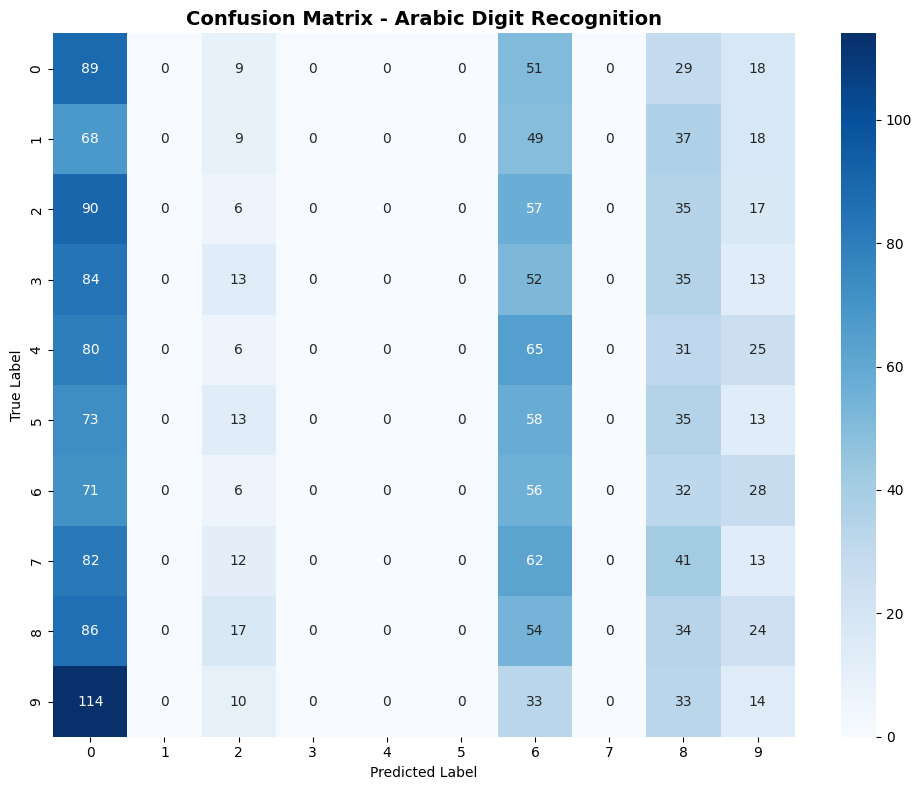


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0       0.11      0.45      0.17       196
     Digit 1       0.00      0.00      0.00       181
     Digit 2       0.06      0.03      0.04       205
     Digit 3       0.00      0.00      0.00       197
     Digit 4       0.00      0.00      0.00       207
     Digit 5       0.00      0.00      0.00       192
     Digit 6       0.10      0.29      0.15       193
     Digit 7       0.00      0.00      0.00       210
     Digit 8       0.10      0.16      0.12       215
     Digit 9       0.08      0.07      0.07       204

    accuracy                           0.10      2000
   macro avg       0.04      0.10      0.06      2000
weighted avg       0.05      0.10      0.06      2000


Per-Class Accuracy:
  Digit 0: 0.4541 (196 samples)
  Digit 1: 0.0000 (181 samples)
  Digit 2: 0.0293 (205 samples)
  Digit 3: 0.0000 (197 samples)
  Digit 4: 0.0000 (207 samples)
  Digit 5: 0.0000 (192 samples)
  Dig

In [43]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)]
)
plt.title('Confusion Matrix - Arabic Digit Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=[f'Digit {i}' for i in range(10)]))

# Per-class accuracy
print("\nPer-Class Accuracy:")
for i in range(10):
    class_mask = y_test == i
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask])
    print(f"  Digit {i}: {class_acc:.4f} ({np.sum(class_mask)} samples)")

## 10. Test on Custom Images

Testing on a random test image...


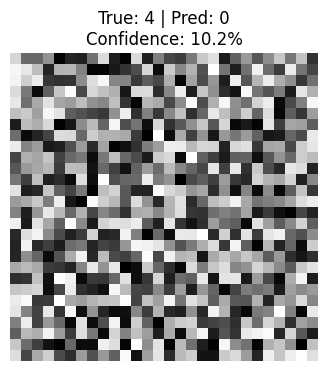


True Label: 4
Predicted: 0 with 10.25% confidence


In [44]:
# ============================================================
# CUSTOM IMAGE PREDICTION PIPELINE
# ============================================================

def preprocess_custom_image(image_path, invert=False):
    """
    Preprocess a custom image for prediction:
    1. Load image in grayscale
    2. Resize to 28x28
    3. Normalize pixels to [0, 1]
    4. Reshape to (1, 28, 28, 1)
    
    Args:
        image_path: Path to the image file
        invert: If True, invert colors (white background -> black background)
    """
    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Resize to 28x28
    img = cv2.resize(img, (28, 28))
    
    # Optional: Invert if background is white
    if invert:
        img = 255 - img
    
    # Normalize
    img = img.astype('float32') / 255.0
    
    # Add batch and channel dimensions
    img = img.reshape(1, 28, 28, 1)
    
    return img

def predict_custom_image(image_path, invert=False):
    """
    Predict digit from a custom image and display results.
    """
    # Preprocess
    processed_img = preprocess_custom_image(image_path, invert)
    
    # Predict
    prediction = model.predict(processed_img, verbose=0)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction)
    
    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Original image
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    ax1.imshow(original, cmap='gray')
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Processed image
    ax2.imshow(processed_img.reshape(28, 28), cmap='gray')
    ax2.set_title(f'Processed (28x28)\nPredicted: {predicted_digit} ({confidence*100:.1f}%)')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print all class probabilities
    print(f"\nPrediction Results for: {image_path}")
    print("-" * 40)
    for i, prob in enumerate(prediction[0]):
        bar = "█" * int(prob * 30)
        marker = " <-- PREDICTED" if i == predicted_digit else ""
        print(f"Digit {i}: {prob*100:6.2f}% {bar}{marker}")
    
    return predicted_digit, confidence

# ============================================================
# TEST WITH CUSTOM IMAGES
# ============================================================

# Example usage (uncomment when you have custom images):
# predict_custom_image('custom_images/sample1.png', invert=True)
# predict_custom_image('custom_images/sample2.png', invert=True)

# For demonstration, test on a random test image
print("Testing on a random test image...")
sample_idx = np.random.randint(0, len(X_test))
sample_img = X_test[sample_idx:sample_idx+1]
sample_label = y_test[sample_idx]

pred = model.predict(sample_img, verbose=0)
pred_digit = np.argmax(pred)
pred_conf = np.max(pred)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title(f'True: {sample_label} | Pred: {pred_digit}\nConfidence: {pred_conf*100:.1f}%')
plt.axis('off')
plt.show()

print(f"\nTrue Label: {sample_label}")
print(f"Predicted: {pred_digit} with {pred_conf*100:.2f}% confidence")

## 11. Save Model

In [45]:
# ============================================================
# SAVE MODEL IN KERAS FORMAT
# ============================================================

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model
keras_path = 'models/arabic_digit_ann.keras'
model.save(keras_path)
print(f"Model saved to: {keras_path}")

# Also save as SavedModel format (optional)
savedmodel_path = 'models/arabic_digit_ann_savedmodel'
model.export(savedmodel_path)

print(f"SavedModel format saved to: {savedmodel_path}")

# Verify the saved model
loaded_model = keras.models.load_model(keras_path)
print(f"\nModel loaded successfully!")
print(f"Input shape: {loaded_model.input_shape}")
print(f"Output shape: {loaded_model.output_shape}")

Model saved to: models/arabic_digit_ann.keras
INFO:tensorflow:Assets written to: models/arabic_digit_ann_savedmodel\assets


INFO:tensorflow:Assets written to: models/arabic_digit_ann_savedmodel\assets


Saved artifact at 'models/arabic_digit_ann_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_44')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1856496379536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496377040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496383184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496383376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496370320: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel format saved to: models/arabic_digit_ann_savedmodel

Model loaded successfully!
Input shape: (None, 28, 28, 1)
Output shape: (None, 10)


## 12. Convert to TensorFlow Lite

In [46]:
# ============================================================
# CONVERT TO TENSORFLOW LITE
# ============================================================

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization settings (optional but recommended for mobile)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Ensure float32 input/output for Flutter compatibility
converter.target_spec.supported_types = [tf.float32]

# Convert
tflite_model = converter.convert()

# Save TFLite model
tflite_path = 'models/arabic_digit_ann.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved to: {tflite_path}")

# Check file size
file_size = os.path.getsize(tflite_path) / 1024  # KB
print(f"TFLite model size: {file_size:.2f} KB ({file_size/1024:.2f} MB)")

INFO:tensorflow:Assets written to: C:\Users\EBRAHI~1\AppData\Local\Temp\tmpo_nlrk7t\assets


INFO:tensorflow:Assets written to: C:\Users\EBRAHI~1\AppData\Local\Temp\tmpo_nlrk7t\assets


Saved artifact at 'C:\Users\EBRAHI~1\AppData\Local\Temp\tmpo_nlrk7t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_44')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1856496379536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496376848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496377040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496383184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496383376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1856496370320: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved to: models/arabic_digit_ann.tflite
TFLite model size: 951.95 KB (0.93 MB)


## 13. Test TensorFlow Lite Model

In [47]:
# ============================================================
# VERIFY TFLITE MODEL COMPATIBILITY
# ============================================================

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("=" * 60)
print("TENSORFLOW LITE MODEL VERIFICATION")
print("=" * 60)

print("\nINPUT DETAILS:")
for detail in input_details:
    print(f"  Name: {detail['name']}")
    print(f"  Shape: {detail['shape']}")
    print(f"  Dtype: {detail['dtype']}")
    print(f"  Expected: [1, 28, 28, 1]")

print("\nOUTPUT DETAILS:")
for detail in output_details:
    print(f"  Name: {detail['name']}")
    print(f"  Shape: {detail['shape']}")
    print(f"  Dtype: {detail['dtype']}")
    print(f"  Expected: [1, 10]")

# Test inference with TFLite
test_input = np.array(X_test[0:1], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])

print("\nINFERENCE TEST:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {tflite_output.shape}")
print(f"  Predicted digit: {np.argmax(tflite_output)}")
print(f"  Confidence: {np.max(tflite_output)*100:.2f}%")

# Compare with original model
keras_output = model.predict(test_input, verbose=0)
print(f"\n  Keras model prediction: {np.argmax(keras_output)}")
print(f"  TFLite model prediction: {np.argmax(tflite_output)}")
print(f"  Match: {np.argmax(keras_output) == np.argmax(tflite_output)}")

print("\n" + "=" * 60)
print("✓ TFLite model is ready for Flutter integration!")
print("=" * 60)

# Copy to Flutter assets (optional)
flutter_assets_path = '../flutter_app/assets/model/arabic_digit_ann.tflite'
if os.path.exists('../flutter_app/assets/model/'):
    import shutil
    shutil.copy(tflite_path, flutter_assets_path)
    print(f"\nModel copied to Flutter assets: {flutter_assets_path}")

TENSORFLOW LITE MODEL VERIFICATION

INPUT DETAILS:
  Name: serving_default_keras_tensor_44:0
  Shape: [ 1 28 28  1]
  Dtype: <class 'numpy.float32'>
  Expected: [1, 28, 28, 1]

OUTPUT DETAILS:
  Name: StatefulPartitionedCall_1:0
  Shape: [ 1 10]
  Dtype: <class 'numpy.float32'>
  Expected: [1, 10]

INFERENCE TEST:
  Input shape: (1, 28, 28, 1)
  Output shape: (1, 10)
  Predicted digit: 0
  Confidence: 10.27%

  Keras model prediction: 0
  TFLite model prediction: 0
  Match: True

✓ TFLite model is ready for Flutter integration!


## 14. Summary & Export Checklist

In [48]:
print("=" * 70)
print("PROJECT SUMMARY - ARABIC HANDWRITTEN DIGIT RECOGNITION")
print("=" * 70)
print(f"\nModel Architecture: Fully Connected Neural Network (ANN)")
print(f"Input Shape:  (28, 28, 1) - Grayscale images")
print(f"Output Shape: (10,) - Digits 0-9")
print(f"Total Parameters: {total_params:,}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nFiles Generated:")
print(f"  ✓ models/arabic_digit_ann.keras (Keras model)")
print(f"  ✓ models/arabic_digit_ann.tflite (TensorFlow Lite)")
print(f"  ✓ training_curves.png (Training visualization)")
print(f"  ✓ confusion_matrix.png (Evaluation visualization)")

print("\nFlutter Integration Checklist:")
print(f"  [ ] Copy arabic_digit_ann.tflite to flutter_app/assets/model/")
print(f"  [ ] Update pubspec.yaml to include assets/model/")
print(f"  [ ] Ensure input shape [1, 28, 28, 1] in Flutter code")
print(f"  [ ] Ensure output shape [1, 10] in Flutter code")
print(f"  [ ] Preprocess: resize to 28x28, grayscale, normalize/255")

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)

PROJECT SUMMARY - ARABIC HANDWRITTEN DIGIT RECOGNITION

Model Architecture: Fully Connected Neural Network (ANN)
Input Shape:  (28, 28, 1) - Grayscale images
Output Shape: (10,) - Digits 0-9
Total Parameters: 242,762
Test Accuracy: 0.0995
Test Loss: 2.3022

Files Generated:
  ✓ models/arabic_digit_ann.keras (Keras model)
  ✓ models/arabic_digit_ann.tflite (TensorFlow Lite)
  ✓ training_curves.png (Training visualization)
  ✓ confusion_matrix.png (Evaluation visualization)

Flutter Integration Checklist:
  [ ] Copy arabic_digit_ann.tflite to flutter_app/assets/model/
  [ ] Update pubspec.yaml to include assets/model/
  [ ] Ensure input shape [1, 28, 28, 1] in Flutter code
  [ ] Ensure output shape [1, 10] in Flutter code
  [ ] Preprocess: resize to 28x28, grayscale, normalize/255

NOTEBOOK EXECUTION COMPLETE
